# Bayes Ingenuo (Gaussiano) : (Gaussian) Naive Bayes

Angelica Mata Zamora

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
from collections import Counter 

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score  
from sklearn.metrics import confusion_matrix

from sklearn.naive_bayes import GaussianNB

In [7]:
mypath = "/Users/hanjeannettezamora/Desktop/Codigos Curso/pima-indians-diabetes.csv"

data = pd.read_csv(mypath, sep=",", header='infer')
data.head(3)

,6,148,72,35,0,33.6,0.627,50,1
0,1,85,66,29,0,26.6,0.351,31,0
1,8,183,64,0,0,23.3,0.672,32,1
2,1,89,66,23,94,28.1,0.167,21,0


In [9]:
data.columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

# Verificar
data.head()

# Ahora sí, separar X y Y
X = data[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']]
Y = data[['Outcome']]

In [10]:
Counter(Y['Outcome'])

Counter({0: 500, 1: 267})

In [11]:
Xtrain, Xtest, ytrain, ytest = train_test_split(X, Y, train_size=0.7, random_state=7)

print(Xtrain.shape)
print(Xtest.shape)
print(ytrain.shape)
print(ytest.shape)

(536, 8)
(231, 8)
(536, 1)
(231, 1)


In [12]:
kfold = KFold(n_splits=10, random_state=7, shuffle=True)
modeloGNB = GaussianNB()
sol = cross_val_score(modeloGNB, Xtrain, np.ravel(ytrain), cv=kfold)
print(sol.mean())

0.7498602375960867


In [13]:
modeloGNB.fit(Xtrain, np.ravel(ytrain))
yhat = modeloGNB.predict(Xtest)

cm = confusion_matrix(ytest, np.ravel(yhat))    # los renglones son los reales y las columnas las predicciones.
print(cm)

[[130  26]
 [ 34  41]]


In [14]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import RocCurveDisplay 

In [15]:
modelokNN = KNeighborsClassifier().fit(Xtrain, np.ravel(ytrain))
modelokNN.score(Xtest,ytest)

0.7359307359307359

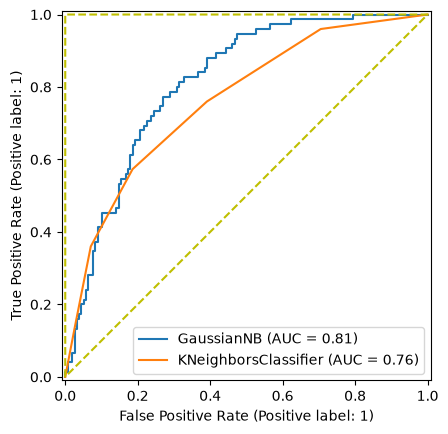

In [16]:
gnb_curve = RocCurveDisplay.from_estimator(modeloGNB, Xtest, ytest)
knn_curve = RocCurveDisplay.from_estimator(modelokNN, Xtest, ytest, ax=gnb_curve.ax_)

plt.plot([0,0,1,0],[0,1,1,0], 'y--')
plt.show() 